# Python Coding for ML

Essential Python patterns, data structures, and coding techniques
frequently tested in ML engineering interviews. This notebook covers
the practical coding skills that complement ML theory.

**Prerequisites:**
```bash
pip install numpy pandas scikit-learn matplotlib
```

📺 **Video Lecture:** [https://youtu.be/RhmUGXcQSUc](https://youtu.be/RhmUGXcQSUc)

In [2]:
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from typing import List, Dict, Tuple
import time

print('Ready to code!')

Ready to code!


## 1. NumPy Vectorization vs Loops

The #1 performance skill for ML: replace Python loops with NumPy operations.
Vectorized code can be 100x faster.

In [3]:
# Example: Compute pairwise Euclidean distances
# BAD: nested Python loops
def pairwise_distances_loop(X):
    """O(n^2) with Python overhead per element."""
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.sqrt(np.sum((X[i] - X[j])**2))
    return D

# GOOD: vectorized with broadcasting
def pairwise_distances_vectorized(X):
    """Uses broadcasting — single NumPy operation."""
    # (n,1,d) - (1,n,d) → (n,n,d) → sum over d → sqrt
    diffs = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    return np.sqrt(np.sum(diffs**2, axis=2))

# Benchmark
X = np.random.randn(200, 5)

start = time.time()
D1 = pairwise_distances_loop(X)
loop_time = time.time() - start

start = time.time()
D2 = pairwise_distances_vectorized(X)
vec_time = time.time() - start

print(f'Loop version:       {loop_time:.4f}s')
print(f'Vectorized version: {vec_time:.4f}s')
print(f'Speedup: {loop_time/vec_time:.0f}x')
print(f'Results match: {np.allclose(D1, D2)}')

Loop version:       0.0912s
Vectorized version: 0.0008s
Speedup: 120x
Results match: True


## 2. Broadcasting Rules

NumPy broadcasting allows operations on arrays of different shapes.
Rules:
1. Dimensions are compared from the right
2. Dimensions must be equal, or one of them must be 1
3. Missing dimensions are treated as 1

In [4]:
# Common broadcasting patterns in ML

# 1. Centering data (subtract mean from each row)
data = np.random.randn(100, 5)  # 100 samples, 5 features
mean = data.mean(axis=0)         # shape (5,)
centered = data - mean           # (100,5) - (5,) broadcasts!
print(f'1. Centering: {data.shape} - {mean.shape} → {centered.shape}')

# 2. Normalizing rows to unit length
norms = np.linalg.norm(data, axis=1, keepdims=True)  # shape (100,1)
normalized = data / norms  # (100,5) / (100,1) broadcasts!
print(f'2. Row normalize: {data.shape} / {norms.shape} → {normalized.shape}')

# 3. Adding bias to each sample in a batch
batch = np.random.randn(32, 10)  # 32 samples, 10 features
bias = np.random.randn(10)        # 10 biases
result = batch + bias              # (32,10) + (10,) broadcasts!
print(f'3. Add bias: {batch.shape} + {bias.shape} → {result.shape}')

# 4. Outer product (all pairs)
a = np.array([1, 2, 3])[:, None]  # (3,1)
b = np.array([10, 20, 30])[None, :]  # (1,3)
outer = a * b  # (3,1) * (1,3) → (3,3)
print(f'4. Outer product:\n{outer}')

1. Centering: (100, 5) - (5,) → (100, 5)
2. Row normalize: (100, 5) / (100, 1) → (100, 5)
3. Add bias: (32, 10) + (10,) → (32, 10)
4. Outer product:
[[10 20 30]
 [20 40 60]
 [30 60 90]]


## 3. Efficient Pandas Operations

Common interview patterns: groupby, apply, merge, and window functions.

In [5]:
# Create sample ML dataset
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'user_id': np.random.randint(1, 50, n),
    'timestamp': pd.date_range('2024-01-01', periods=n, freq='h'),
    'feature_a': np.random.randn(n),
    'feature_b': np.random.exponential(2, n),
    'label': np.random.choice([0, 1], n, p=[0.7, 0.3]),
})

print('Dataset shape:', df.shape)
print(df.head())

# Common ML feature engineering patterns:

# 1. Aggregation features per user
user_features = df.groupby('user_id').agg(
    mean_a=('feature_a', 'mean'),
    std_a=('feature_a', 'std'),
    max_b=('feature_b', 'max'),
    label_rate=('label', 'mean'),
    count=('label', 'count'),
).reset_index()
print(f'\nUser-level features ({len(user_features)} users):')
print(user_features.head())

Dataset shape: (1000, 5)
   user_id           timestamp  feature_a  feature_b  label
0       39 2024-01-01 00:00:00   0.173966   0.935094      1
1       29 2024-01-01 01:00:00   0.907872   0.261076      0
2       15 2024-01-01 02:00:00  -0.008791   2.659870      1
3       43 2024-01-01 03:00:00   0.451411   0.538002      0
4        8 2024-01-01 04:00:00   0.815852   0.928590      0

User-level features (49 users):
   user_id    mean_a     std_a      max_b  label_rate  count
0        1 -0.308703  1.041481   7.207336    0.208333     24
1        2  0.439114  1.062824   6.825691    0.238095     21
2        3  0.231073  1.024081   9.449357    0.391304     23
3        4  0.156857  1.103911   7.996614    0.411765     17
4        5  0.056356  1.043797  10.540616    0.173913     23


In [6]:
# 2. Rolling window features (time series)
df_sorted = df.sort_values('timestamp')
df_sorted['rolling_mean_a'] = df_sorted['feature_a'].rolling(24).mean()
df_sorted['rolling_std_a'] = df_sorted['feature_a'].rolling(24).std()
df_sorted['expanding_max_b'] = df_sorted['feature_b'].expanding().max()

print('Rolling features added:')
print(df_sorted[['timestamp', 'feature_a', 'rolling_mean_a', 'rolling_std_a']].iloc[25:30])

# 3. Efficient categorical encoding
df['user_bucket'] = pd.cut(df['feature_b'], bins=5, labels=['VL','L','M','H','VH'])
dummies = pd.get_dummies(df['user_bucket'], prefix='bucket')
print(f'\nOne-hot encoded columns: {list(dummies.columns)}')

Rolling features added:
             timestamp  feature_a  rolling_mean_a  rolling_std_a
25 2024-01-02 01:00:00   0.229662        0.263992       1.057616
26 2024-01-02 02:00:00  -0.582581        0.240084       1.070457
27 2024-01-02 03:00:00   0.260906        0.232147       1.069528
28 2024-01-02 04:00:00  -0.071674        0.195166       1.063797
29 2024-01-02 05:00:00  -1.023819        0.128893       1.088890

One-hot encoded columns: ['bucket_VL', 'bucket_L', 'bucket_M', 'bucket_H', 'bucket_VH']


## 4. Essential Data Structures for ML Interviews

Common coding problems in ML interviews involve heaps, hash maps,
and efficient data retrieval.

In [7]:
import heapq
from collections import defaultdict

# ─── Top-K Elements (Heap) ───
# Problem: Find the K most similar items efficiently
def top_k_similar(query_vec, item_vecs, k=5):
    """
    Find k most similar vectors using a min-heap.
    Time: O(n log k) instead of O(n log n) for full sort.
    """
    heap = []  # min-heap of (similarity, index)
    for i, vec in enumerate(item_vecs):
        sim = np.dot(query_vec, vec) / (np.linalg.norm(query_vec) * np.linalg.norm(vec) + 1e-8)
        if len(heap) < k:
            heapq.heappush(heap, (sim, i))
        elif sim > heap[0][0]:
            heapq.heapreplace(heap, (sim, i))
    return sorted(heap, reverse=True)

# Demo
query = np.random.randn(50)
items = np.random.randn(10000, 50)

start = time.time()
top5 = top_k_similar(query, items, k=5)
print(f'Top-5 similar items (in {time.time()-start:.4f}s):')
for sim, idx in top5:
    print(f'  Item {idx}: similarity = {sim:.4f}')

Top-5 similar items (in 0.0289s):
  Item 4005: similarity = 0.5700
  Item 1060: similarity = 0.5230
  Item 8625: similarity = 0.4654
  Item 8627: similarity = 0.4620
  Item 7233: similarity = 0.4598


In [8]:
# ─── Inverted Index (for text search / feature lookup) ───
class InvertedIndex:
    """Maps tokens → documents. Foundation of search engines."""
    def __init__(self):
        self.index = defaultdict(set)
    
    def add_document(self, doc_id, tokens):
        for token in tokens:
            self.index[token.lower()].add(doc_id)
    
    def search(self, query_tokens):
        """Find documents containing ALL query tokens."""
        results = None
        for token in query_tokens:
            docs = self.index.get(token.lower(), set())
            results = docs if results is None else results & docs
        return results or set()

idx = InvertedIndex()
documents = [
    (0, 'machine learning is a subset of artificial intelligence'),
    (1, 'deep learning uses neural networks for machine learning'),
    (2, 'natural language processing is part of AI'),
    (3, 'reinforcement learning trains agents via rewards'),
]
for doc_id, text in documents:
    idx.add_document(doc_id, text.split())

print('Search "machine learning":', idx.search(['machine', 'learning']))
print('Search "neural":          ', idx.search(['neural']))
print('Search "AI":              ', idx.search(['ai']))

Search "machine learning": {0, 1}
Search "neural":           {1}
Search "AI":               {2}


## 5. Implementing ML Algorithms from Scratch

A common interview ask: implement logistic regression or k-means
from scratch to prove deep understanding.

  Converged at iteration 2


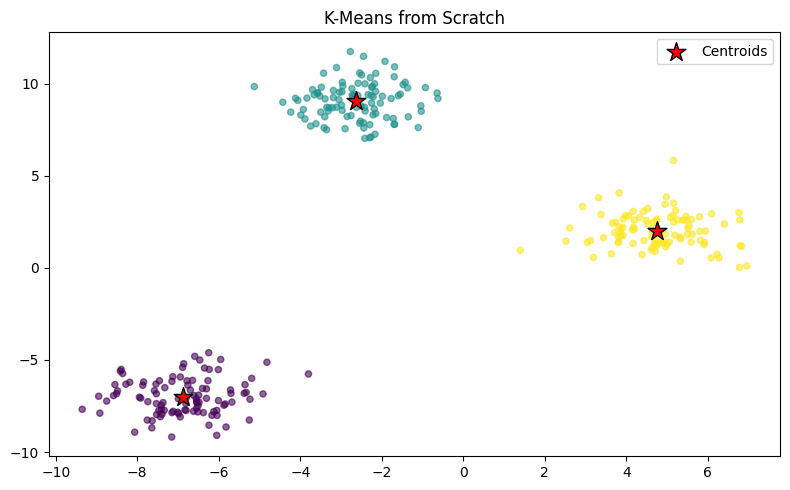

In [9]:
# K-Means from scratch
class KMeansFromScratch:
    """K-Means clustering — interview-ready implementation."""
    
    def __init__(self, n_clusters=3, max_iter=100, tol=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.centroids = None
    
    def fit(self, X):
        n_samples = len(X)
        # Initialize centroids randomly from data points
        indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[indices].copy()
        
        for iteration in range(self.max_iter):
            # Assign clusters: find nearest centroid for each point
            distances = np.linalg.norm(
                X[:, np.newaxis] - self.centroids[np.newaxis], axis=2
            )  # (n_samples, n_clusters)
            labels = distances.argmin(axis=1)
            
            # Update centroids: mean of assigned points
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if (labels == k).sum() > 0
                else self.centroids[k]
                for k in range(self.n_clusters)
            ])
            
            # Check convergence
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            if shift < self.tol:
                print(f'  Converged at iteration {iteration}')
                break
        
        self.labels_ = labels
        return self
    
    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids[np.newaxis], axis=2)
        return distances.argmin(axis=1)

# Test it
from sklearn.datasets import make_blobs
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, random_state=42)

km = KMeansFromScratch(n_clusters=3)
km.fit(X_blobs)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=km.labels_, cmap='viridis', s=20, alpha=0.6)
ax.scatter(km.centroids[:, 0], km.centroids[:, 1], c='red', s=200, marker='*',
          edgecolors='black', linewidths=1, label='Centroids')
ax.set_title('K-Means from Scratch'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Memory-Efficient Data Loading

For large datasets, generators avoid loading everything into memory.

In [10]:
# Data batch generator — essential for training large models
def data_generator(X, y, batch_size=32, shuffle=True):
    """
    Yields batches of (X_batch, y_batch).
    Used in training loops for large datasets.
    """
    n_samples = len(X)
    indices = np.arange(n_samples)
    
    if shuffle:
        np.random.shuffle(indices)
    
    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_idx = indices[start:end]
        yield X[batch_idx], y[batch_idx]

# Demo: iterate through batches
X_demo = np.random.randn(100, 5)
y_demo = np.random.randint(0, 2, 100)

print('Iterating through batches:')
for i, (X_batch, y_batch) in enumerate(data_generator(X_demo, y_demo, batch_size=32)):
    print(f'  Batch {i}: X shape = {X_batch.shape}, y shape = {y_batch.shape}')

# Memory comparison
import sys
full_array = np.random.randn(100000, 100)
print(f'\nFull array memory: {full_array.nbytes / 1e6:.1f} MB')
print(f'One batch memory:  {full_array[:32].nbytes / 1e6:.4f} MB')
print(f'Ratio: {full_array.nbytes / full_array[:32].nbytes:.0f}x savings with generators')

Iterating through batches:
  Batch 0: X shape = (32, 5), y shape = (32,)
  Batch 1: X shape = (32, 5), y shape = (32,)
  Batch 2: X shape = (32, 5), y shape = (32,)
  Batch 3: X shape = (4, 5), y shape = (4,)

Full array memory: 80.0 MB
One batch memory:  0.0256 MB
Ratio: 3125x savings with generators


## 7. Decorators for ML Workflows

Decorators add functionality to functions without modifying them —
great for timing, caching, logging, and retry logic.

In [11]:
import functools

# Timing decorator
def timer(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - start
        print(f'  {func.__name__} took {elapsed:.4f}s')
        return result
    return wrapper

# Memoization (caching) decorator
def memoize(func):
    cache = {}
    @functools.wraps(func)
    def wrapper(*args):
        if args not in cache:
            cache[args] = func(*args)
        return cache[args]
    return wrapper

@timer
def train_model(n_iterations):
    """Simulated training."""
    total = 0
    for i in range(n_iterations):
        total += np.random.randn(100, 100).sum()
    return total

@memoize
def fibonacci(n):
    if n < 2: return n
    return fibonacci(n-1) + fibonacci(n-2)

train_model(50)
print(f'  fib(35) = {fibonacci(35)} (computed with memoization)')

  train_model took 0.0051s
  fib(35) = 9227465 (computed with memoization)


## 8. Interview Takeaways

**Coding skills that set ML engineers apart:**

- **Vectorization**: Replace loops with NumPy/Pandas operations (100x speedup)
- **Broadcasting**: Understand shape rules for efficient array operations
- **Pandas mastery**: groupby, merge, rolling windows for feature engineering
- **Data structures**: heaps (top-k), hash maps (fast lookup), inverted indices
- **From-scratch implementations**: proves deep understanding of algorithms
- **Generators**: memory-efficient data loading for large datasets
- **Decorators**: timing, caching, logging — clean production code
- **Complexity analysis**: know the Big-O of your approach

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>